# RiskLens — Risk Analysis Walkthrough

This notebook walks through the full RiskLens pipeline: data ingestion, historical risk analysis, and Monte Carlo simulation — progressively adding model complexity to show how each layer improves risk estimation.

| Step | Shocks | Volatility | What it adds |
|------|--------|------------|--------------|
| 1. Baseline | Normal | Constant | Textbook GBM |
| 2. Fat tails | Student-t | Constant | Heavier tails, more extreme events |
| 3. Vol clustering | Normal | GARCH(1,1) | Time-varying volatility |
| 4. Regimes | Normal | HMM (2 regimes) | Regime-specific drift + volatility |
| 5. ML volatility | Normal | XGBoost (21d) | Data-driven volatility prediction |

In [41]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from src.data.fetch import fetch_asset_data
from src.data.process import clean_market_data, add_returns
from src.analytics.risk_metrics import (
    annualized_volatility, rolling_volatility, max_drawdown,
    drawdown_series, sharpe_ratio, sortino_ratio, gain_to_pain_ratio,
    best_worst_periods, return_statistics,
)
from src.analytics.monte_carlo import (
    simulate_paths, simulation_summary, compute_var, compute_cvar,
    prob_target, scenario_buckets, fit_t_distribution, fit_garch,
    fit_hmm, predict_current_regime, fit_rvol, predict_current_vol,
)

sns.set_theme(style="whitegrid")
%matplotlib inline

## 1. Data Ingestion

Fetch historical OHLCV data via yfinance, clean it, and compute daily returns.

In [42]:
TICKER = "BTC-USD"
N_DAYS = 252
N_SIMS = 10_000
SEED = 42

raw = fetch_asset_data(TICKER)
df = clean_market_data(raw)
df = add_returns(df)
returns = df["returns"]
close = df["close"]
initial_price = close.iloc[-1]

print(f"Loaded {len(df)} trading days for {TICKER}")
print(f"Initial price: ${initial_price:,.0f}")
df.tail()

Loaded 1824 trading days for BTC-USD
Initial price: $68,982


,open,high,low,close,volume,returns,log_returns
date,,,,,,,
2026-04-01,68232.890625,69230.359375,67555.359375,68078.554688,36465393617,-0.002268,-0.002271
2026-04-02,68077.898438,68633.148438,65725.257812,66888.570312,39323384518,-0.017480,-0.017634
2026-04-03,66889.015625,67296.234375,66281.539062,66931.101562,22815543346,0.000636,0.000636
2026-04-04,66938.648438,67515.015625,66769.640625,67290.515625,15878814963,0.005370,0.005356
2026-04-05,67291.195312,69087.656250,66610.632812,68981.898438,22972648674,0.025136,0.024825


## 2. Historical Risk Metrics

In [43]:
print(f"Annualized Volatility: {annualized_volatility(returns):.2%}")
print(f"Max Drawdown:          {max_drawdown(close):.2%}")
print(f"Sharpe Ratio:          {sharpe_ratio(returns):.3f}")
print(f"Sortino Ratio:         {sortino_ratio(returns):.3f}")
print(f"Gain-to-Pain Ratio:    {gain_to_pain_ratio(returns):.3f}")
print()
bw = best_worst_periods(returns, window=21)
print(f"Best 21-Day Return:    {bw['best']:.2%}")
print(f"Worst 21-Day Return:   {bw['worst']:.2%}")

Annualized Volatility: 46.70%
Max Drawdown:          -76.63%
Sharpe Ratio:          0.295
Sortino Ratio:         0.413
Gain-to-Pain Ratio:    0.056

Best 21-Day Return:    47.85%
Worst 21-Day Return:   -48.31%


## 3. Historical Charts

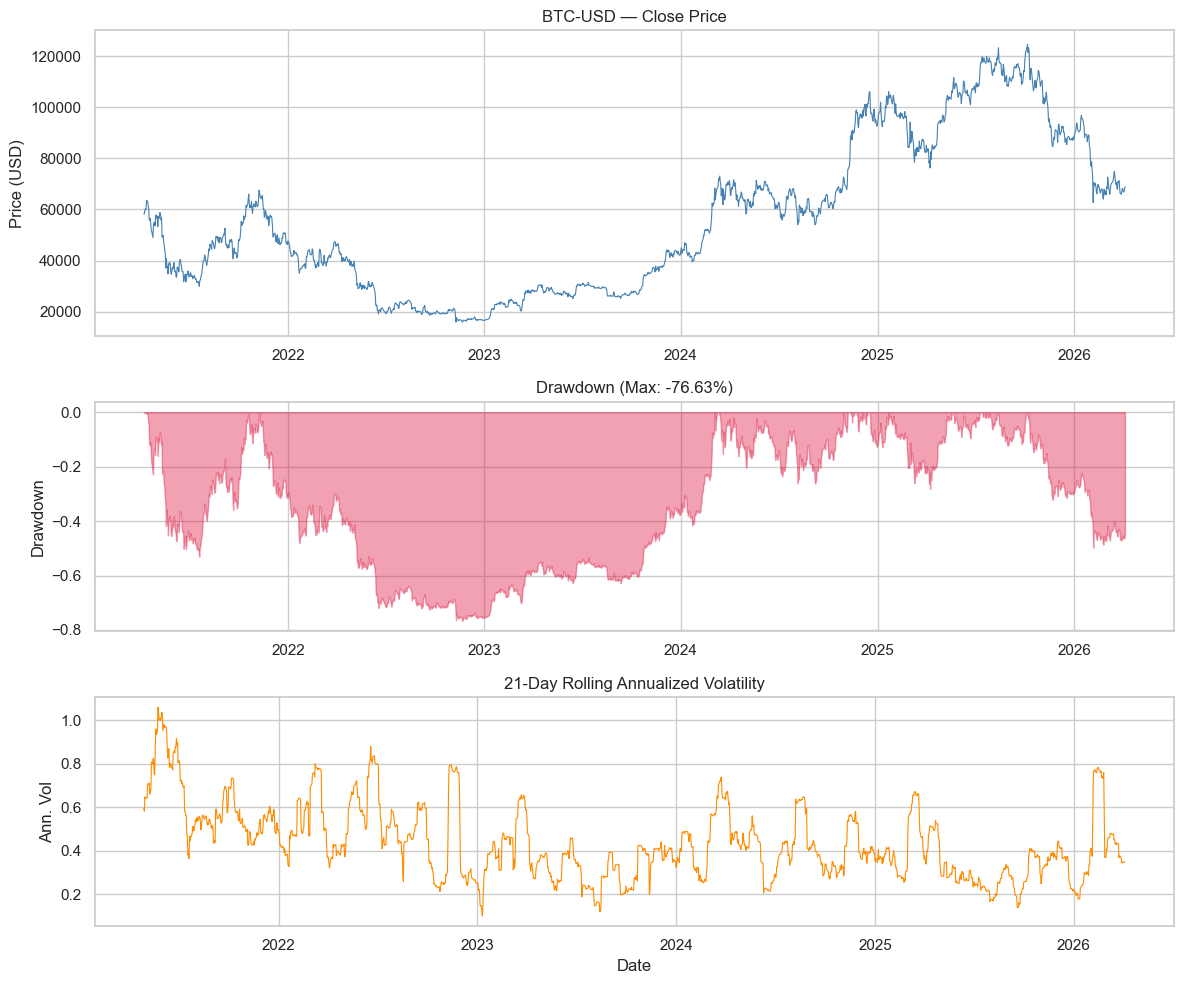

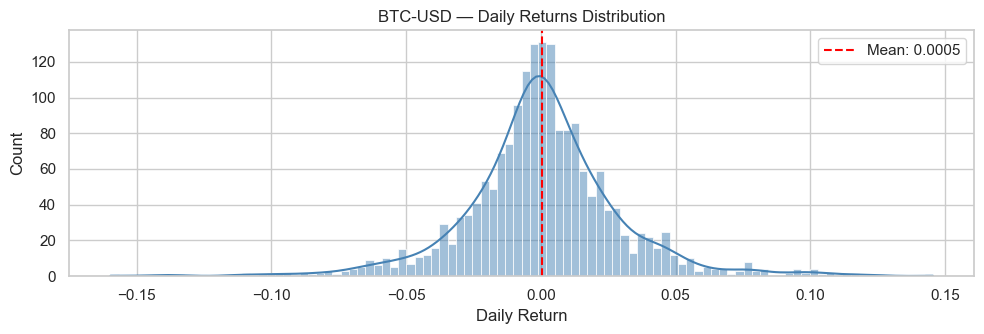

In [44]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), gridspec_kw={"height_ratios": [2, 1.5, 1.5]})

# Price & drawdown
axes[0].plot(close.index, close.values, color="steelblue", linewidth=0.8)
axes[0].set_title(f"{TICKER} — Close Price")
axes[0].set_ylabel("Price (USD)")

dd = drawdown_series(close)
axes[1].fill_between(dd.index, dd.values, 0, color="crimson", alpha=0.4)
axes[1].set_title(f"Drawdown (Max: {max_drawdown(close):.2%})")
axes[1].set_ylabel("Drawdown")

# Rolling vol
rol_vol = rolling_volatility(returns, window=21)
axes[2].plot(rol_vol.index, rol_vol.values, color="darkorange", linewidth=0.8)
axes[2].set_title("21-Day Rolling Annualized Volatility")
axes[2].set_ylabel("Ann. Vol")
axes[2].set_xlabel("Date")

plt.tight_layout()
plt.show()

# Returns distribution
fig, ax = plt.subplots(figsize=(10, 3.5))
sns.histplot(returns, bins=100, kde=True, ax=ax, color="steelblue")
ax.axvline(returns.mean(), color="red", linestyle="--", label=f"Mean: {returns.mean():.4f}")
ax.set_title(f"{TICKER} — Daily Returns Distribution")
ax.set_xlabel("Daily Return")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Monte Carlo — Baseline (Normal + Constant)

The simplest model: Geometric Brownian Motion with constant drift and volatility, Gaussian shocks.

In [45]:
# We'll collect all models here for the final comparison
all_models = {}

def run_model(name, **kwargs):
    """Run MC simulation and store results."""
    paths = simulate_paths(close, returns, n_days=N_DAYS, n_simulations=N_SIMS, seed=SEED, **kwargs)
    fp = paths.iloc[-1]
    s95 = simulation_summary(fp, initial_price, confidence=0.95)
    s99 = simulation_summary(fp, initial_price, confidence=0.99)
    all_models[name] = {
        "paths": paths, "final_prices": fp,
        "var_95": s95["var"], "cvar_95": s95["cvar"],
        "var_99": s99["var"], "cvar_99": s99["cvar"],
        "prob_gain": s95["prob_gain"], "mean_price": s95["mean_final_price"],
        "median_price": s95["median_final_price"],
    }
    return paths, fp, s95

# Baseline
paths_base, fp_base, s_base = run_model("Normal + Constant")

print(f"P(Gain): {s_base['prob_gain']:.1%}  |  P(Loss): {s_base['prob_loss']:.1%}")
print(f"VaR (95%): {s_base['var']:.2%}  |  CVaR (95%): {s_base['cvar']:.2%}")
print(f"Mean: ${s_base['mean_final_price']:,.0f}  |  Median: ${s_base['median_final_price']:,.0f}")

P(Gain): 52.5%  |  P(Loss): 47.5%
VaR (95%): -52.24%  |  CVaR (95%): -60.21%
Mean: $78,843  |  Median: $70,899


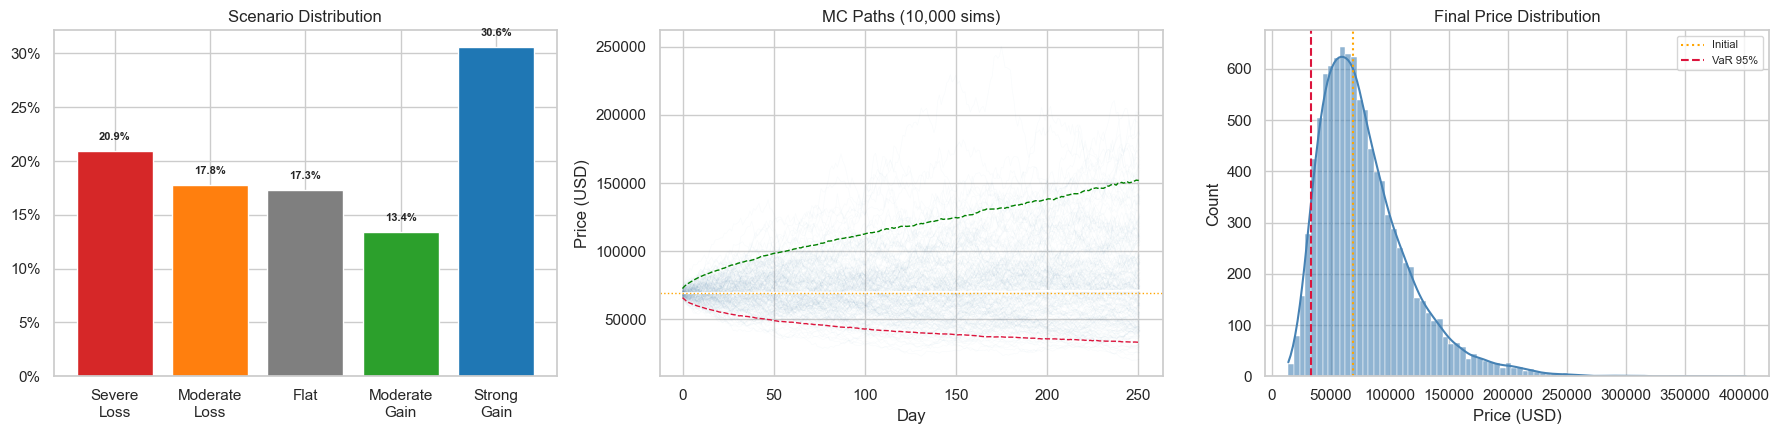

In [46]:
# Scenario distribution + paths + final price dist
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

# Scenarios
scenarios = scenario_buckets(fp_base, initial_price)
labels = ["Severe\nLoss", "Moderate\nLoss", "Flat", "Moderate\nGain", "Strong\nGain"]
colors_sc = ["#d62728", "#ff7f0e", "#7f7f7f", "#2ca02c", "#1f77b4"]
bars = axes[0].bar(labels, list(scenarios.values()), color=colors_sc, edgecolor="white")
for bar, val in zip(bars, scenarios.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{val:.1%}", ha="center", fontsize=8, fontweight="bold")
axes[0].set_title("Scenario Distribution")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

# Paths
sample = paths_base.iloc[:, :200]
axes[1].plot(sample, color="steelblue", alpha=0.03, linewidth=0.5)
axes[1].plot(paths_base.median(axis=1), color="white", linewidth=1.5)
axes[1].plot(paths_base.quantile(0.05, axis=1), color="crimson", linewidth=1, linestyle="--")
axes[1].plot(paths_base.quantile(0.95, axis=1), color="green", linewidth=1, linestyle="--")
axes[1].axhline(initial_price, color="orange", linewidth=1, linestyle=":")
axes[1].set_title(f"MC Paths ({N_SIMS:,} sims)")
axes[1].set_xlabel("Day")
axes[1].set_ylabel("Price (USD)")

# Final price dist
var_price = initial_price * (1 + s_base["var"])
sns.histplot(fp_base, bins=80, kde=True, ax=axes[2], color="steelblue", alpha=0.6)
axes[2].axvline(initial_price, color="orange", linewidth=1.5, linestyle=":", label=f"Initial")
axes[2].axvline(var_price, color="crimson", linewidth=1.5, linestyle="--", label=f"VaR 95%")
axes[2].set_title("Final Price Distribution")
axes[2].set_xlabel("Price (USD)")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 5. Adding Fat Tails — Student-t Shocks

Real financial returns have heavier tails than a normal distribution. Student-t captures extreme events that GBM misses.

In [47]:
t_info = fit_t_distribution(returns)
print(f"Student-t fit: df = {t_info['df']:.2f} ({t_info['tail_description']})")

_, fp_t, s_t = run_model("Student-t + Constant", distribution="t", df_t=t_info["df"])

print(f"\nBaseline  VaR: {s_base['var']:.2%}  |  CVaR: {s_base['cvar']:.2%}")
print(f"Student-t VaR: {s_t['var']:.2%}  |  CVaR: {s_t['cvar']:.2%}")
print(f"  -> Fat tails deepen CVaR by {abs(s_t['cvar']) - abs(s_base['cvar']):.2%} (more conservative)")

Student-t fit: df = 2.75 (Very heavy tails)

Baseline  VaR: -52.24%  |  CVaR: -60.21%
Student-t VaR: -50.59%  |  CVaR: -59.80%
  -> Fat tails deepen CVaR by -0.41% (more conservative)


## 6. Adding Volatility Clustering — GARCH(1,1)

Volatility is not constant — high-vol periods cluster together. GARCH models this time-varying behavior.

In [48]:
garch_info = fit_garch(returns)
print(f"GARCH(1,1): α={garch_info['alpha']:.4f}, β={garch_info['beta']:.4f}, "
      f"persistence={garch_info['persistence']:.4f}, long-run vol={garch_info['long_run_vol']:.2%}")

_, fp_g, s_g = run_model("Normal + GARCH", volatility_model="garch", garch_params=garch_info)

print(f"\nBaseline VaR: {s_base['var']:.2%}  |  GARCH VaR: {s_g['var']:.2%}")
print(f"Baseline CVaR: {s_base['cvar']:.2%}  |  GARCH CVaR: {s_g['cvar']:.2%}")

GARCH(1,1): α=0.0853, β=0.8792, persistence=0.9646, long-run vol=48.30%

Baseline VaR: -52.24%  |  GARCH VaR: -53.12%
Baseline CVaR: -60.21%  |  GARCH CVaR: -61.19%


## 7. Regime Detection — HMM (2 Regimes)

Markets alternate between calm and crisis regimes, each with distinct drift and volatility. A Hidden Markov Model learns these states and their transition dynamics.

In [49]:
hmm_info = fit_hmm(returns, n_regimes=2, seed=SEED)
current = predict_current_regime(hmm_info, returns)

for i, p in enumerate(hmm_info["regime_params"]):
    label = "Calm" if i == 0 else "Crisis"
    marker = " <- current" if i == current else ""
    print(f"  {label}: mu={p['mu']:.6f}, sigma={p['sigma']:.4f} (ann. {p['sigma']*np.sqrt(252):.2%}){marker}")

_, fp_hmm, s_hmm = run_model("Normal + HMM-2", volatility_model="hmm", hmm_params=hmm_info)

print(f"\nBaseline VaR: {s_base['var']:.2%}  |  HMM-2 VaR: {s_hmm['var']:.2%}")
print(f"Baseline CVaR: {s_base['cvar']:.2%}  |  HMM-2 CVaR: {s_hmm['cvar']:.2%}")

  Calm: mu=0.000260, sigma=0.0169 (ann. 26.86%) <- current
  Crisis: mu=0.001166, sigma=0.0463 (ann. 73.57%)

Baseline VaR: -52.24%  |  HMM-2 VaR: -52.38%
Baseline CVaR: -60.21%  |  HMM-2 CVaR: -59.94%


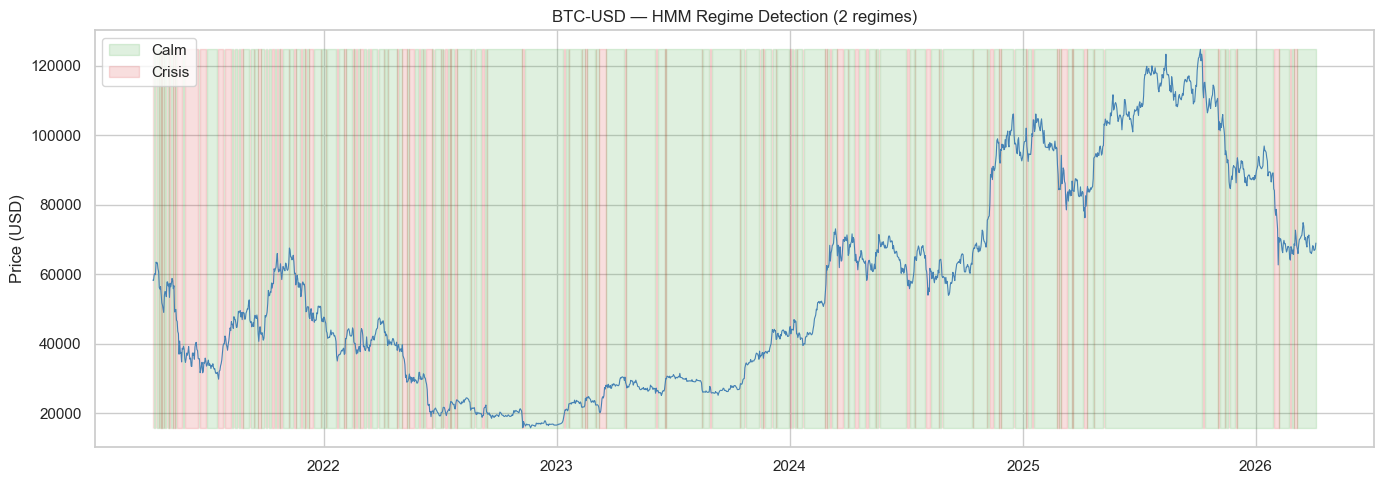

In [50]:
# Regime overlay on price chart
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(close.index, close.values, color="steelblue", linewidth=0.8)
labels_hmm = hmm_info["regime_labels"]
dates = close.index[:len(labels_hmm)]
prices = close.values[:len(labels_hmm)]
regime_colors = {0: "#2ca02c", 1: "#d62728"}
for r, name in [(0, "Calm"), (1, "Crisis")]:
    mask = labels_hmm == r
    ax.fill_between(dates, prices.min(), prices.max(), where=mask,
                    alpha=0.15, color=regime_colors[r], label=name)
ax.set_title(f"{TICKER} — HMM Regime Detection (2 regimes)")
ax.set_ylabel("Price (USD)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## 8. ML Volatility — XGBoost (21-day horizon)

Instead of parametric models, we use XGBoost to predict forward realized volatility from rolling features.

In [51]:
rvol_info = fit_rvol(returns, horizon=21, seed=SEED)
pred_vol = rvol_info["predicted_vol"]

print(f"XGBoost (21d) — Predicted daily vol: {pred_vol:.4f} (ann. {pred_vol * np.sqrt(252):.2%})")
print(f"R² (train): {rvol_info['r2_train']:.3f}")
print(f"Historical daily vol: {returns.std():.4f} (ann. {annualized_volatility(returns):.2%})")

_, fp_rvol, s_rvol = run_model("Normal + XGBoost-21d", volatility_model="rvol", rvol_params=rvol_info)

print(f"\nBaseline VaR: {s_base['var']:.2%}  |  XGBoost VaR: {s_rvol['var']:.2%}")
print(f"Baseline CVaR: {s_base['cvar']:.2%}  |  XGBoost CVaR: {s_rvol['cvar']:.2%}")

XGBoost (21d) — Predicted daily vol: 0.0318 (ann. 50.49%)
R² (train): 0.770
Historical daily vol: 0.0294 (ann. 46.70%)

Baseline VaR: -52.24%  |  XGBoost VaR: -55.95%
Baseline CVaR: -60.21%  |  XGBoost CVaR: -63.80%


## 9. Full Comparison

All five models side by side — how does each layer change the risk picture?

In [52]:
# Summary table
rows = []
for name, r in all_models.items():
    rows.append({
        "Model": name,
        "VaR 95%": f"{r['var_95']:.2%}", "CVaR 95%": f"{r['cvar_95']:.2%}",
        "VaR 99%": f"{r['var_99']:.2%}", "CVaR 99%": f"{r['cvar_99']:.2%}",
        "P(Gain)": f"{r['prob_gain']:.1%}",
        "Mean Price": f"${r['mean_price']:,.0f}",
        "Median Price": f"${r['median_price']:,.0f}",
    })
pd.DataFrame(rows).set_index("Model")

,VaR 95%,CVaR 95%,VaR 99%,CVaR 99%,P(Gain),Mean Price,Median Price
Model,,,,,,,
Normal + Constant,-52.24%,-60.21%,-65.65%,-70.15%,52.5%,"$78,843","$70,899"
Student-t + Constant,-50.59%,-59.80%,-65.62%,-72.34%,52.5%,"$79,071","$71,112"
Normal + GARCH,-53.12%,-61.19%,-67.17%,-72.20%,52.1%,"$78,746","$70,890"
Normal + HMM-2,-52.38%,-59.94%,-64.88%,-70.36%,52.3%,"$78,859","$70,853"
Normal + XGBoost-21d,-55.95%,-63.80%,-69.15%,-73.48%,50.9%,"$78,806","$69,596"


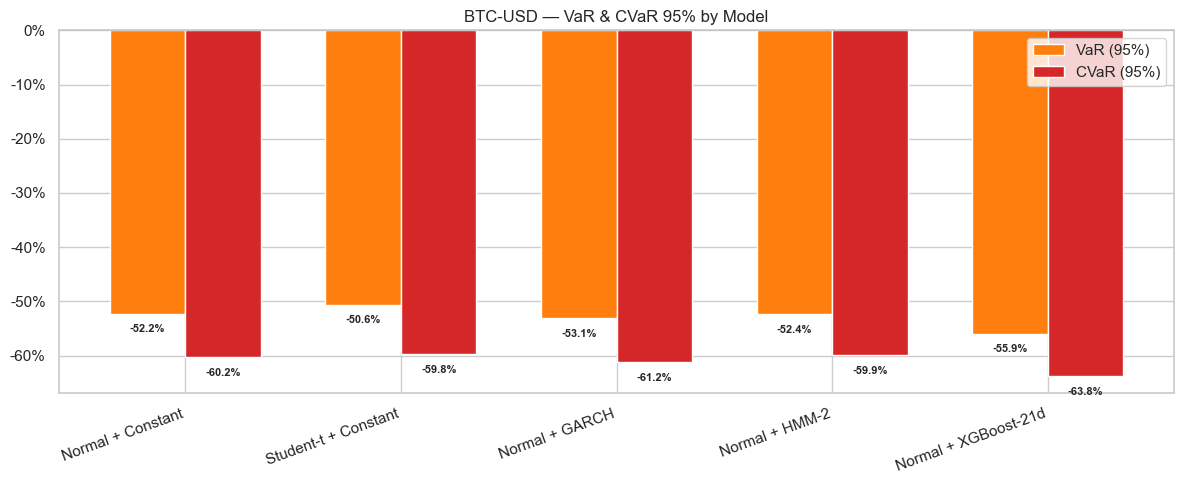

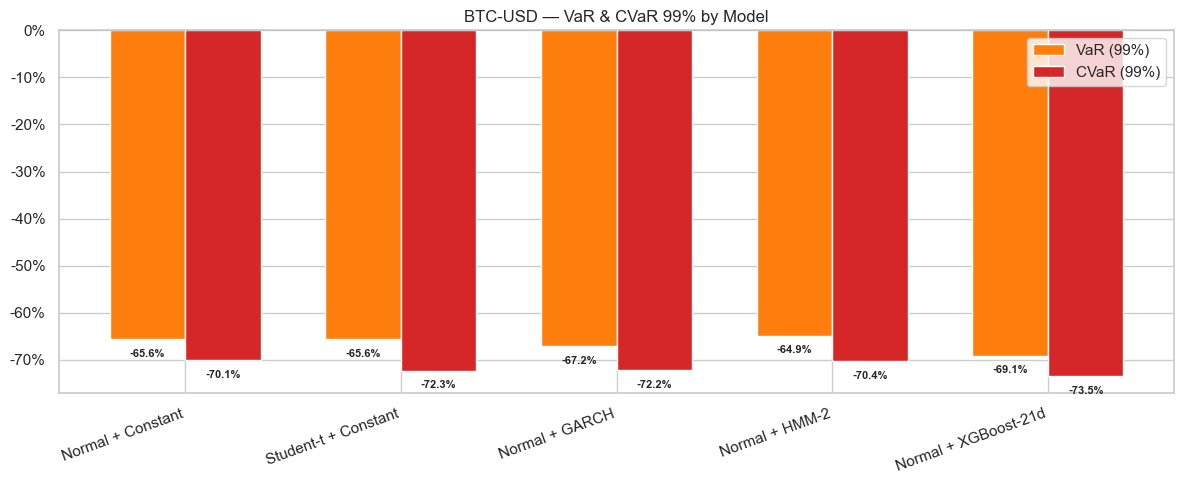

In [53]:
# VaR & CVaR bar charts (95% and 99%)
model_names = list(all_models.keys())
x = np.arange(len(model_names))
width = 0.35

for conf, vk, ck in [("95%", "var_95", "cvar_95"), ("99%", "var_99", "cvar_99")]:
    fig, ax = plt.subplots(figsize=(12, 5))
    vars_ = [all_models[m][vk] for m in model_names]
    cvars_ = [all_models[m][ck] for m in model_names]
    b1 = ax.bar(x - width/2, vars_, width, label=f"VaR ({conf})", color="#ff7f0e")
    b2 = ax.bar(x + width/2, cvars_, width, label=f"CVaR ({conf})", color="#d62728")
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=20, ha="right")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.set_title(f"{TICKER} — VaR & CVaR {conf} by Model")
    ax.legend()
    ax.axhline(0, color="gray", linewidth=0.5)
    for bars in [b1, b2]:
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.02,
                    f"{bar.get_height():.1%}", ha="center", va="top", fontsize=8, fontweight="bold")
    plt.tight_layout()
    plt.show()

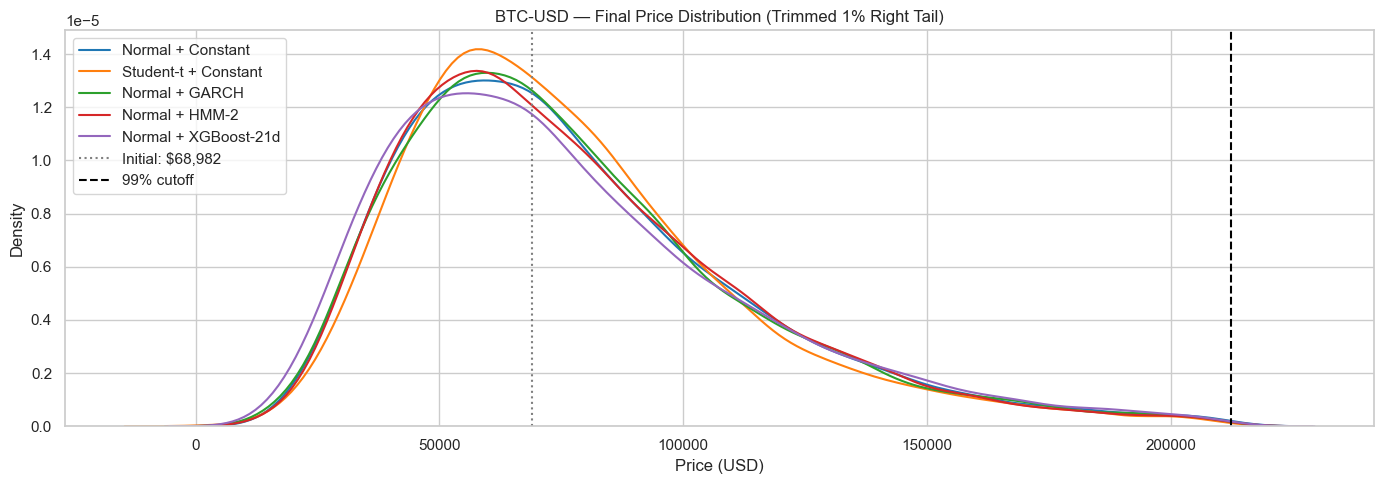

In [56]:
fig, ax = plt.subplots(figsize=(14, 5))

colors_m = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

# threshold global (importante para comparar modelos)
all_prices = np.concatenate([r["final_prices"] for r in all_models.values()])
p99 = np.percentile(all_prices, 99)

for (name, r), c in zip(all_models.items(), colors_m):
    data = r["final_prices"]
    
    # cortar cola derecha
    data_trimmed = data[data <= p99]
    
    sns.kdeplot(data_trimmed, ax=ax, label=name, color=c, linewidth=1.5)

ax.axvline(initial_price, color="gray", linewidth=1.5, linestyle=":", label=f"Initial: ${initial_price:,.0f}")
ax.axvline(p99, color="black", linestyle="--", label="99% cutoff")

ax.set_title(f"{TICKER} — Final Price Distribution (Trimmed 1% Right Tail)")
ax.set_xlabel("Price (USD)")
ax.legend()

plt.tight_layout()
plt.show()

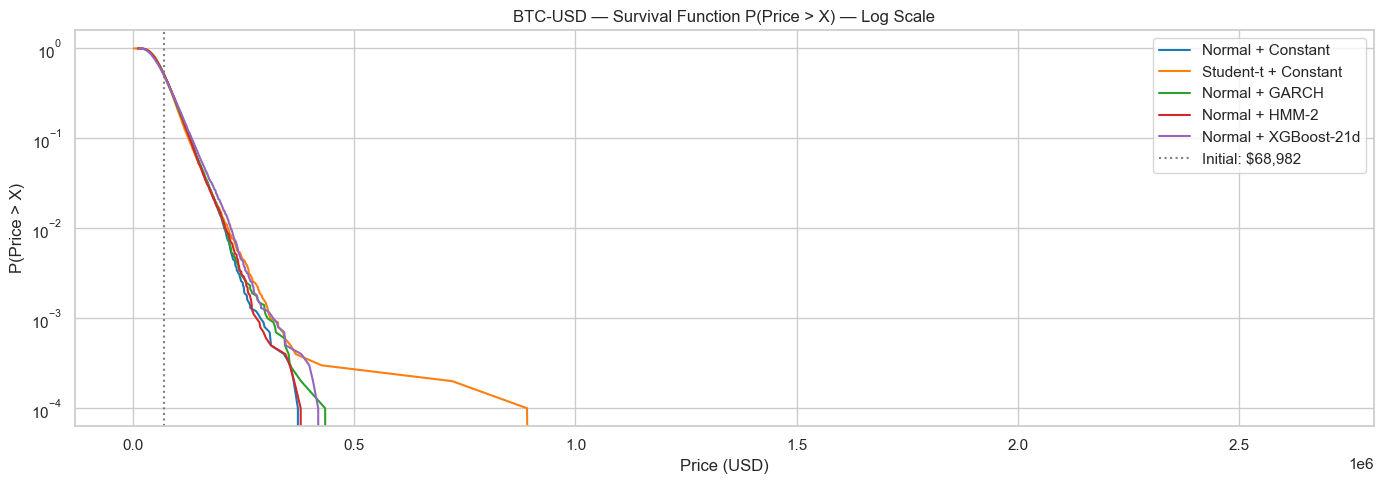

In [55]:
# Survival function (log-scale) — tail behavior
fig, ax = plt.subplots(figsize=(14, 5))
for (name, r), c in zip(all_models.items(), colors_m):
    sorted_p = np.sort(r["final_prices"])
    survival = 1 - np.arange(1, len(sorted_p) + 1) / len(sorted_p)
    ax.plot(sorted_p, survival, label=name, color=c, linewidth=1.5)
ax.axvline(initial_price, color="gray", linewidth=1.5, linestyle=":", label=f"Initial: ${initial_price:,.0f}")
ax.set_yscale("log")
ax.set_title(f"{TICKER} — Survival Function P(Price > X) — Log Scale")
ax.set_xlabel("Price (USD)")
ax.set_ylabel("P(Price > X)")
ax.legend()
plt.tight_layout()
plt.show()

## 10. Key Takeaways

- **Normal + Constant** (baseline GBM) underestimates tail risk — thinnest tails, lowest kurtosis.
- **Student-t** fattens both tails symmetrically — worst-case and best-case become more extreme, VaR/CVaR deepen.
- **GARCH** adapts volatility to the current regime — if we're in a high-vol period, the simulation fan widens accordingly.
- **HMM Regimes** go further: each regime has its own **drift and volatility**, capturing the asymmetry that crashes are fast with high vol while rallies are slower with low vol.
- **XGBoost** provides a data-driven volatility estimate using 12 rolling features — the predicted vol reflects the current market state, not just a parametric model.
- The difference in **CVaR** between baseline and the most conservative model is the risk you miss by using textbook assumptions.
- Each layer adds realism — the right choice depends on the use case, data availability, and how much model complexity you can explain to stakeholders.